,Cycles,Capacity (Ah)
0,0,100.352810
1,50,99.080031
2,100,98.195748
3,150,97.448179
4,200,96.373512


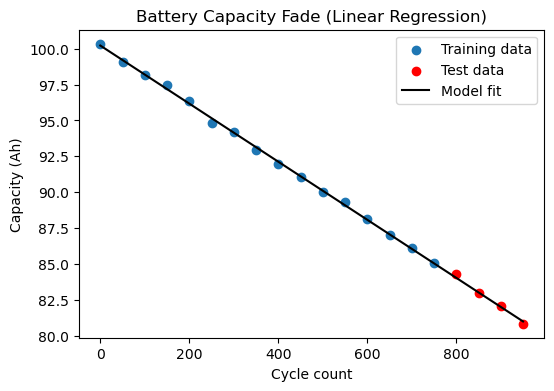

Predicted capacity at 800 cycles: 84.03 Ah
Predicted capacity at 850 cycles: 83.01 Ah
Predicted capacity at 900 cycles: 82.00 Ah
Predicted capacity at 950 cycles: 80.99 Ah


In [1]:
# === Basic ML Demo: Predict Battery Capacity from Cycle Count ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Simulated battery degradation data
np.random.seed(0)
cycles = np.arange(0, 1000, 50)
capacity = 100 - 0.02 * cycles + np.random.normal(0, 0.2, len(cycles))  # 100Ah initial, small noise

# Create DataFrame
df = pd.DataFrame({'Cycles': cycles, 'Capacity (Ah)': capacity})
display(df.head())

# Train/test split
train = df.iloc[:-4]
test = df.iloc[-4:]

# Fit simple linear regression
model = LinearRegression()
model.fit(train[['Cycles']], train['Capacity (Ah)'])

# Predict on test set
pred = model.predict(test[['Cycles']])

# Plot
plt.figure(figsize=(6,4))
plt.scatter(train['Cycles'], train['Capacity (Ah)'], label='Training data')
plt.scatter(test['Cycles'], test['Capacity (Ah)'], color='red', label='Test data')
plt.plot(df['Cycles'], model.predict(df[['Cycles']]), color='black', label='Model fit')
plt.xlabel('Cycle count')
plt.ylabel('Capacity (Ah)')
plt.legend()
plt.title('Battery Capacity Fade (Linear Regression)')
plt.show()

# Display prediction
for c, p in zip(test['Cycles'], pred):
    print(f"Predicted capacity at {c} cycles: {p:.2f} Ah")


In [2]:
%matplotlib qt